> **Snap Market model series.** We start from Carl's baseline momentum model and iterate to test it and improve it.
>
> **Notebook 03 — make the baseline rolling.** Recalibrate Carl's momentum model on a rolling (walk-forward) window instead of one fixed split, and compare rolling vs static out-of-sample.

# 03 — Rolling vs static momentum-lookup (out-of-sample)

Compare the house performance of the two momentum-lookup models on the **same** out-of-sample
period:

- `momentum_lookup` — calibrated once on a fixed 40% split.
- `momentum_lookup_rolling` — recalibrated walk-forward on a trailing 90-day window (weekly).

First under **uninformed random flow**, then against **informed attackers**. Both models are
evaluated from the **common evaluation start** (the later of the two valid start dates) over
identical, non-overlapping windows with identical random seeds, so the only thing that differs
is the displayed fair-price curve.

In [1]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

In [2]:
from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features
from snapmarket.parameters import SharedParameters
from snapmarket.models import build_model
from snapmarket.experiments import common_evaluation_start
from snapmarket.strategies import noise_pool
from snapmarket.engine import simulate

shared_parameters = SharedParameters()
features = build_features(load_oracle_prices(), shared_parameters)

models = {
    "static": build_model("momentum_lookup", features, shared_parameters),
    "rolling": build_model("momentum_lookup_rolling", features, shared_parameters),
}

evaluation_start = common_evaluation_start(models.values())
print(f"common evaluation start: second {evaluation_start:,} (~{evaluation_start / 86_400:.0f} days in)")
for label, model in models.items():
    print(f"  {label:8s} first valid second = {model.first_evaluation_index:,}")

common evaluation start: second 7,776,605 (~90 days in)
  static   first valid second = 6,589,805
  rolling  first valid second = 7,776,605


## Part 1 — Uninformed random flow

Slice the out-of-sample tail into non-overlapping windows. In each window, replay a balanced
noise pool through **both** models with the same seed and record the house edge
(house PnL / volume). Identical flow in, only the displayed curve differs.

In [3]:
import numpy as np
import pandas as pd

window_length = 200_000          # seconds per window
number_of_windows = 8            # raise for a longer evaluation
base_stake = 50.0

rows = []
for window_index in range(number_of_windows):
    start = evaluation_start + window_index * window_length
    if start + window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
        break
    seed = 1_000 + window_index
    for label, model in models.items():
        result = simulate(model, features, {"noise": noise_pool(base_stake=base_stake)},
                          start, window_length, seed=seed)
        rows.append({
            "window": window_index,
            "model": label,
            "house_edge": result.house_edge,
            "house_pnl": result.house_pnl,
            "volume": result.total_volume,
        })

results = pd.DataFrame(rows)
print(f"{results['window'].nunique()} windows of {window_length:,} seconds each")
results.pivot(index="window", columns="model", values="house_edge")[["static", "rolling"]]

8 windows of 200,000 seconds each


model,static,rolling
window,,
0,0.128384,0.128415
1,0.131316,0.131274
2,0.125337,0.125443
3,0.127742,0.127830
4,0.130686,0.130662
5,0.128300,0.128413
6,0.126487,0.126756
7,0.127315,0.127484


In [4]:
summary = (results
           .groupby("model")
           .agg(mean_house_edge=("house_edge", "mean"),
                std_house_edge=("house_edge", "std"),
                total_house_pnl=("house_pnl", "sum"),
                total_volume=("volume", "sum"))
           .reindex(["static", "rolling"]))
summary["aggregate_house_edge"] = summary["total_house_pnl"] / summary["total_volume"]

print(summary.to_string(formatters={
    "mean_house_edge": "{:+.3%}".format,
    "std_house_edge": "{:.3%}".format,
    "total_house_pnl": "${:,.0f}".format,
    "total_volume": "${:,.0f}".format,
    "aggregate_house_edge": "{:+.3%}".format,
}))

difference_basis_points = 1e4 * (summary.loc["rolling", "aggregate_house_edge"]
                                 - summary.loc["static", "aggregate_house_edge"])
print(f"\nrolling - static aggregate house edge: {difference_basis_points:+.1f} basis points")

        mean_house_edge std_house_edge total_house_pnl total_volume aggregate_house_edge
model                                                                                   
static         +12.820%         0.200%     $10,247,430  $79,937,696             +12.819%
rolling        +12.828%         0.192%     $10,254,556  $79,937,696             +12.828%

rolling - static aggregate house edge: +0.9 basis points


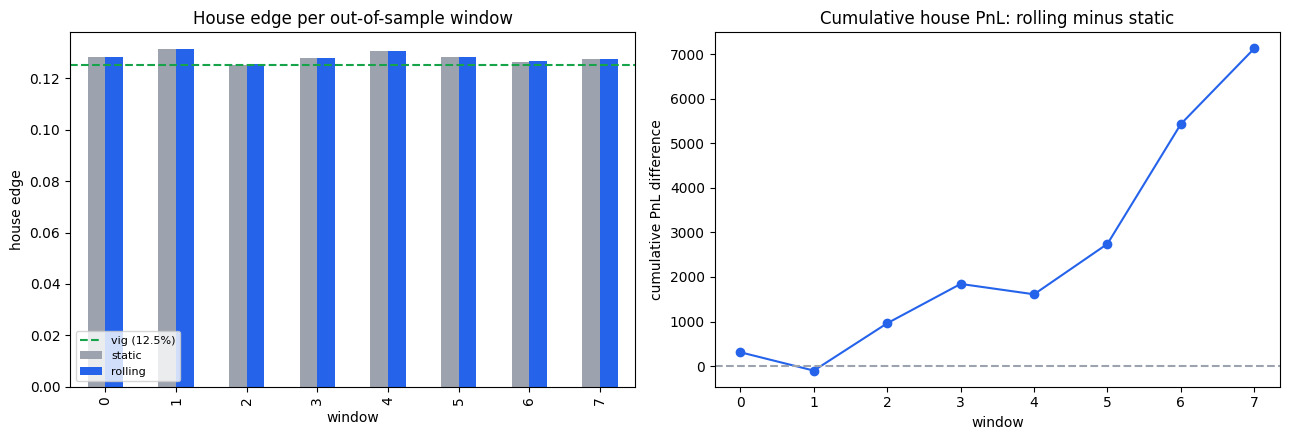

In [5]:
import matplotlib.pyplot as plt

edge_by_window = results.pivot(index="window", columns="model", values="house_edge")[["static", "rolling"]]
pnl_difference = (results.pivot(index="window", columns="model", values="house_pnl")["rolling"]
                  - results.pivot(index="window", columns="model", values="house_pnl")["static"]).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

edge_by_window.plot(kind="bar", ax=axes[0], color={"static": "#9ca3af", "rolling": "#2563eb"})
axes[0].axhline(shared_parameters.house_margin, ls="--", color="#16a34a",
                label=f"vig ({shared_parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window")
axes[0].set_xlabel("window"); axes[0].set_ylabel("house edge")
axes[0].legend(fontsize=8)

pnl_difference.plot(ax=axes[1], marker="o", color="#2563eb")
axes[1].axhline(0, ls="--", color="#9ca3af")
axes[1].set_title("Cumulative house PnL: rolling minus static")
axes[1].set_xlabel("window"); axes[1].set_ylabel("cumulative PnL difference")

plt.tight_layout(); plt.show()

## Part 2 — Informed attackers

A bettor only beats the house if it knows something the displayed curve does not. We test three
informed archetypes inside the same balanced noise pool, isolating the attacker's PnL, and see
how the **static** and **rolling** models hold up against each:

- **predictive (logistic)** — a walk-forward logistic estimate of P(up) on many features; bets the positive expected-value side at the quoted odds.
- **lead-lag (fast feed)** — uses the faster Binance feed that leads the settlement oracle.
- **regime-aware** — P(up) calibrated per volatility regime, exposing where the single momentum curve is wrong.

A positive attacker edge means it beats the house; an uninformed bettor sits near minus the vig.

In [6]:
from snapmarket.data import load_fast_feed
from snapmarket.signals import walk_forward_logistic_probability, regime_conditional_probability
from snapmarket.strategies import predictive_bettor, lead_lag_bettor, regime_aware_bettor

fast_feed = load_fast_feed(expected_length=features.number_of_seconds)

logistic_probability = walk_forward_logistic_probability(features, shared_parameters)
regime_probability = regime_conditional_probability(features, shared_parameters)

informed_attackers = {
    "predictive (logistic)": predictive_bettor(logistic_probability),
    "lead-lag (fast feed)": lead_lag_bettor(features, fast_feed.log_price),
    "regime-aware": regime_aware_bettor(regime_probability),
}
print("informed attackers:", list(informed_attackers))

informed attackers: ['predictive (logistic)', 'lead-lag (fast feed)', 'regime-aware']


Each attacker bets inside a noise pool over the common out-of-sample windows (same seeds for
both models). We report the attacker's isolated edge (its PnL / its stake) and its share of
volume, for the static and the rolling model.

In [7]:
informed_window_length = 150_000
informed_number_of_windows = 6

attacker_rows = []
for model_label, model in models.items():
    for attacker_label, bettor in informed_attackers.items():
        attacker_pnl = attacker_stake = total_volume = 0.0
        for window_index in range(informed_number_of_windows):
            start = evaluation_start + window_index * informed_window_length
            if start + informed_window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
                break
            result = simulate(model, features,
                              {"pool": noise_pool(), "attacker": bettor},
                              start, informed_window_length, seed=200 + window_index)
            outcome = result.per_bettor["attacker"]
            attacker_pnl += outcome.pnl
            attacker_stake += outcome.stake
            total_volume += result.total_volume
        attacker_rows.append({
            "attacker": attacker_label,
            "model": model_label,
            "attacker_edge": attacker_pnl / attacker_stake if attacker_stake else 0.0,
            "attacker_pnl": attacker_pnl,
            "volume_share": attacker_stake / total_volume if total_volume else 0.0,
        })

attacker_results = pd.DataFrame(attacker_rows)
attacker_results.pivot(index="attacker", columns="model", values="attacker_edge")[["static", "rolling"]]

model,static,rolling
attacker,,
lead-lag (fast feed),-0.172810,-0.172596
predictive (logistic),-0.045508,-0.046773
regime-aware,0.044151,0.046678


In [8]:
attacker_edge = attacker_results.pivot(index="attacker", columns="model", values="attacker_edge")[["static", "rolling"]]
volume_share = attacker_results.pivot(index="attacker", columns="model", values="volume_share")[["static", "rolling"]]

print("Attacker edge (PnL / stake), positive = beats the house:\n")
print(attacker_edge.to_string(formatters={"static": "{:+.2%}".format, "rolling": "{:+.2%}".format}))
print("\nAttacker share of volume:\n")
print(volume_share.to_string(formatters={"static": "{:.1%}".format, "rolling": "{:.1%}".format}))

Attacker edge (PnL / stake), positive = beats the house:

model                  static rolling
attacker                             
lead-lag (fast feed)  -17.28% -17.26%
predictive (logistic)  -4.55%  -4.68%
regime-aware           +4.42%  +4.67%

Attacker share of volume:

model                 static rolling
attacker                            
lead-lag (fast feed)   50.0%   50.0%
predictive (logistic)   2.9%    3.0%
regime-aware            6.3%    6.5%


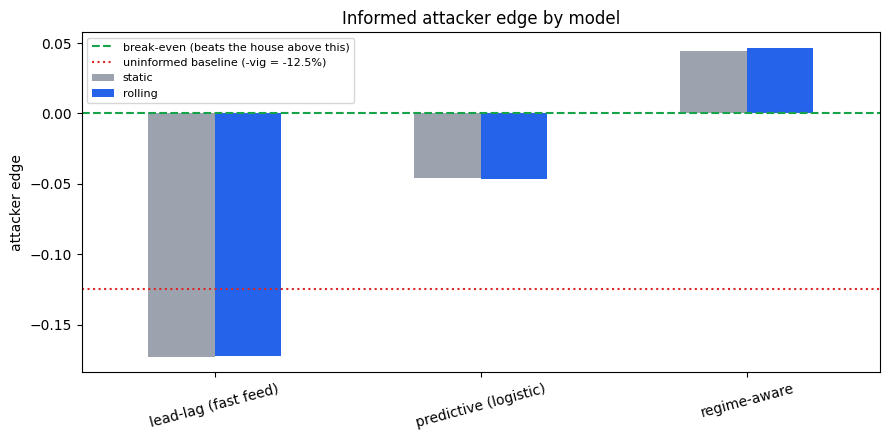

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
attacker_edge.plot(kind="bar", ax=ax, color={"static": "#9ca3af", "rolling": "#2563eb"})
ax.axhline(0, color="#16a34a", ls="--", label="break-even (beats the house above this)")
ax.axhline(-shared_parameters.house_margin, color="#dc2626", ls=":",
           label=f"uninformed baseline (-vig = {-shared_parameters.house_margin:.1%})")
ax.set_title("Informed attacker edge by model")
ax.set_ylabel("attacker edge"); ax.set_xlabel("")
ax.legend(fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()